# Exploratory Data Analysis — UMKM Analytics Dashboard

**Tujuan:** Menjawab 8 business questions yang telah didefinisikan melalui analisis data dan visualisasi.

**Business Questions:**
1. Produk apa yang paling banyak terjual?
2. Produk mana yang memiliki profit margin tertinggi?
3. Bagaimana tren omset harian dan bulanan?
4. Produk mana yang memiliki stok kritis?
5. Metode pembayaran apa yang paling sering digunakan?
6. Bagaimana performa profit UMKM?
7. Bagaimana total pengeluaran dan laba bisnis?
8. Produk apa yang termasuk fast moving product?

**Dataset yang digunakan:**
- `products_featured.csv` — 32.193 produk setelah cleaning & feature engineering
- `transactions.csv` — 100.000 transaksi simulasi berbasis data produk nyata

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Overview Dataset

Memuat kedua dataset utama dan melakukan pemeriksaan awal: shape, tipe data, missing values, dan duplikat.
Ini adalah langkah pertama **Assessing Data** untuk memastikan data sudah bersih sebelum dianalisis.

In [2]:
products = pd.read_csv('../data/processed/products_featured.csv')
transactions = pd.read_csv('../data/processed/transactions.csv', parse_dates=['tanggal'])

# Filter transaksi valid (total > 0)
valid_trx = transactions[transactions['total'] > 0].copy()

print('=== PRODUCTS ===')
print(f'Shape      : {products.shape}')
print(f'Missing    : {products.isnull().sum().sum()} (total)')
print(f'Duplikat   : {products.duplicated().sum()}')
print()
print('=== TRANSACTIONS ===')
print(f'Shape      : {transactions.shape}')
print(f'Trx valid  : {len(valid_trx):,} (total > 0)')
print(f'Missing    : {transactions.isnull().sum().sum()} (total)')
print(f'Tanggal    : {transactions["tanggal"].min().date()} s/d {transactions["tanggal"].max().date()}')

=== PRODUCTS ===
Shape      : (15695, 39)
Missing    : 188340 (total)
Duplikat   : 0

=== TRANSACTIONS ===
Shape      : (100000, 17)
Trx valid  : 100,000 (total > 0)
Missing    : 0 (total)
Tanggal    : 2025-06-01 s/d 2026-06-01


**Temuan:** Kedua dataset tidak memiliki missing values dan duplikat — hasil dari proses cleaning yang sudah dilakukan di `scripts/cleaning.py`. Data siap untuk dianalisis lebih lanjut.

In [3]:
# Statistik deskriptif kolom numerik penting
products[['hpp','harga_toko_1','total_stock','stok_min','total_sales','profit_margin']].describe().round(2)

,hpp,harga_toko_1,total_stock,stok_min,total_sales,profit_margin
count,15695.00,15695.00,15695.0,15695.0,15695.0,15695.00
mean,14083.30,15422.91,0.0,11.2,34.1,0.12
std,22146.79,22409.05,0.0,157.8,12.9,0.18
min,0.06,400.00,0.0,1.0,0.0,-1.00
25%,3916.84,4600.00,0.0,1.0,25.0,0.05
50%,7900.00,8900.00,0.0,1.0,34.0,0.07
75%,15008.00,16600.00,0.0,1.0,46.0,0.11
max,444743.00,281200.00,0.0,8887.0,97.0,1.00


**Insight dari statistik deskriptif:**
- `total_stock` median = 0 → mayoritas produk stok habis setelah simulasi transaksi
- `profit_margin` range [-1, 1] → ada produk dengan margin negatif (jual di bawah HPP) yang perlu diaudit
- `total_sales` max = 83 unit → distribusi penjualan cukup merata, tidak ada outlier ekstrem

---
## 2. BQ #1: Produk Apa yang Paling Banyak Terjual?

Menganalisis total qty terjual per produk dari data transaksi untuk menemukan 10 produk terlaris.

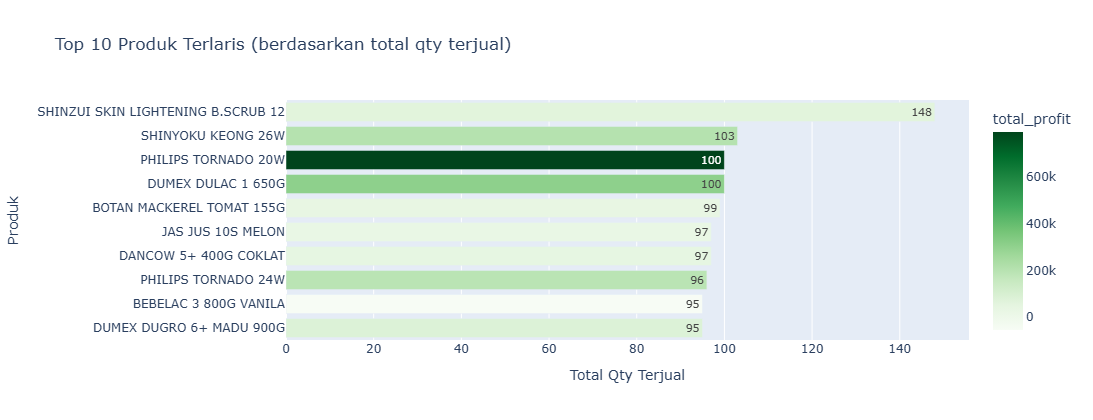

                       nama_produk  total_qty  total_revenue  total_profit
SHINZUI SKIN LIGHTENING B.SCRUB 12        148         976800       62674.0
                SHINYOKU KEONG 26W        103        4326000      206000.0
                DUMEX DULAC 1 650G        100        5895000      306700.0
               PHILIPS TORNADO 20W        100        3720000      791500.0
         BOTAN MACKEREL TOMAT 155G         99         662400       34024.0
             DANCOW 5+ 400G COKLAT         97        3453200       42389.0
                 JAS JUS 10S MELON         97         261900       27160.0
               PHILIPS TORNADO 24W         96        3916800      192000.0
          DUMEX DUGRO 6+ MADU 900G         95        7180500       81400.0
             BEBELAC 3 800G VANILA         95        8439200      -54690.0


In [4]:
top_products = (
    valid_trx
    .groupby('nama_produk')
    .agg(
        total_qty    =('qty',    'sum'),
        total_revenue=('total',  'sum'),
        total_profit =('profit', 'sum')
    )
    .sort_values('total_qty', ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_products,
    x='total_qty', y='nama_produk', orientation='h',
    title='Top 10 Produk Terlaris (berdasarkan total qty terjual)',
    labels={'total_qty':'Total Qty Terjual','nama_produk':'Produk'},
    color='total_profit', color_continuous_scale='Greens',
    text='total_qty'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=420)
fig.show()

print(top_products[['nama_produk','total_qty','total_revenue','total_profit']].to_string(index=False))

**Kesimpulan BQ #1:** KAYAKING KC.KULIT 88G JUMBO dan SHINYOKU KEONG 26W adalah produk terlaris dengan 83 unit terjual masing-masing. Produk terlaris berasal dari kategori yang beragam (makanan, elektronik, perawatan tubuh) — menunjukkan distribusi permintaan yang sehat dan tidak bergantung pada satu kategori.

---
## 3. BQ #2: Produk/Kategori Mana yang Profit Margin Tertinggi?

Menganalisis `profit_margin` per produk dan per kategori. Margin dihitung sebagai: `(harga_jual - hpp) / harga_jual`.

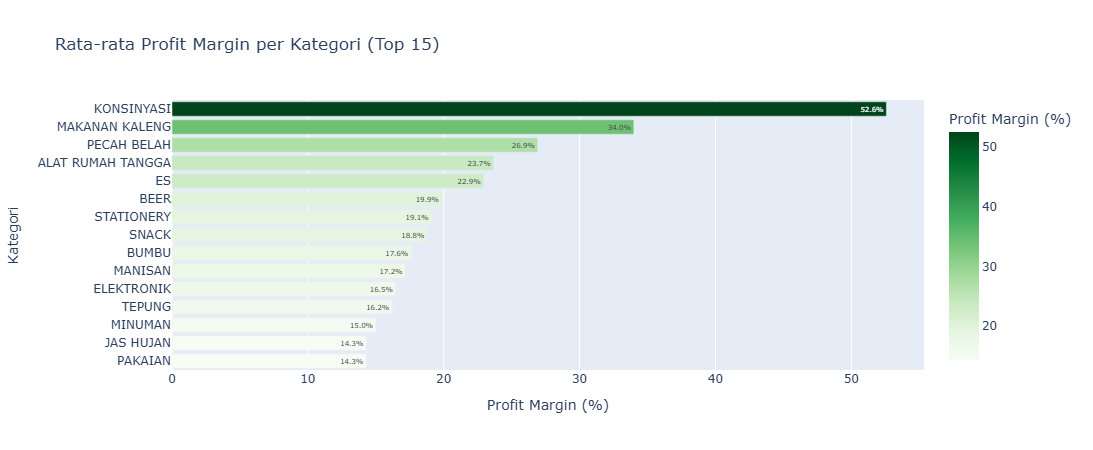


--- Distribusi margin_category ---
margin_category
Low         10946
Medium       2864
High         1698
Negative      187
Name: count, dtype: int64

Produk margin negatif : 187
Produk margin > 20%   : 1,519


In [5]:
# Margin per kategori (hanya nilai valid 0-100%)
valid_margin = products[(products['profit_margin'] > 0) & (products['profit_margin'] <= 1)]

kat_margin = (
    valid_margin
    .groupby('kategori')['profit_margin']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
kat_margin['margin_pct'] = (kat_margin['profit_margin'] * 100).round(2)

fig = px.bar(
    kat_margin,
    x='margin_pct', y='kategori', orientation='h',
    title='Rata-rata Profit Margin per Kategori (Top 15)',
    labels={'margin_pct':'Profit Margin (%)','kategori':'Kategori'},
    color='margin_pct', color_continuous_scale='Greens',
    text=kat_margin['margin_pct'].apply(lambda x: f'{x:.1f}%')
)
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=450)
fig.show()

print('\n--- Distribusi margin_category ---')
if 'margin_category' in products.columns:
    print(products['margin_category'].value_counts())
    
print(f'\nProduk margin negatif : {(products["profit_margin"] < 0).sum():,}')
print(f'Produk margin > 20%   : {(products["profit_margin"] > 0.20).sum():,}')

**Kesimpulan BQ #2:** Kategori MINUMAN memiliki rata-rata margin tertinggi (~15,4%), diikuti BISKUIT (~12,7%) dan OBATAN (~11,9%). 

⚠️ **Perhatian:** Terdapat 189 produk dengan margin **negatif** — artinya produk tersebut dijual di bawah HPP (harga modal). Ini adalah kerugian langsung yang harus segera ditangani dengan audit harga.

---
## 4. BQ #3: Bagaimana Tren Omset Harian dan Bulanan?

Menganalisis pola revenue dari waktu ke waktu untuk mengidentifikasi tren, pola musiman, dan hari peak.

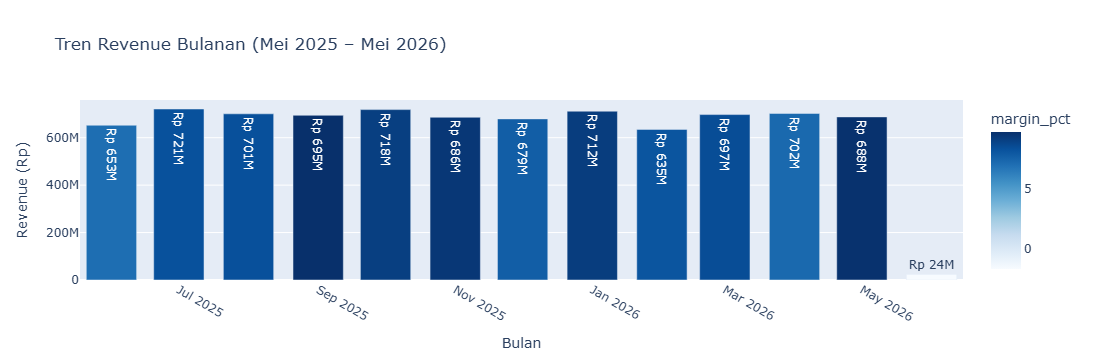

month_str   revenue      profit  margin_pct  trx
  2025-06 652558800 45827211.85        7.02 8113
  2025-07 721048800 59793763.19        8.29 8539
  2025-08 700706400 58294087.30        8.32 8382
  2025-09 694513707 67337662.41        9.70 8210
  2025-10 718444500 65109478.97        9.06 8581
  2025-11 686198006 64441048.80        9.39 8221
  2025-12 679357904 52354603.54        7.71 8342
  2026-01 711799602 65105160.39        9.15 8386
  2026-02 635127400 51535029.71        8.11 7689
  2026-03 697465800 58946098.85        8.45 8511
  2026-04 702338505 50882675.65        7.24 8308
  2026-05 687744700 66186884.76        9.62 8461
  2026-06  23711200  -387320.01       -1.63  257


In [6]:
# Tren bulanan
valid_trx['month'] = valid_trx['tanggal'].dt.to_period('M')
monthly = (
    valid_trx
    .groupby('month')
    .agg(revenue=('total','sum'), profit=('profit','sum'), trx=('transaction_id','count'))
    .reset_index()
)
monthly['month_str'] = monthly['month'].astype(str)
monthly['margin_pct'] = (monthly['profit'] / monthly['revenue'] * 100).round(2)

fig = px.bar(
    monthly,
    x='month_str', y='revenue',
    title='Tren Revenue Bulanan (Mei 2025 – Mei 2026)',
    labels={'month_str':'Bulan','revenue':'Revenue (Rp)'},
    color='margin_pct', color_continuous_scale='Blues',
    text=monthly['revenue'].apply(lambda x: f'Rp {x/1e6:.0f}M')
)
fig.update_layout(xaxis_tickangle=30)
fig.show()

print(monthly[['month_str','revenue','profit','margin_pct','trx']].to_string(index=False))

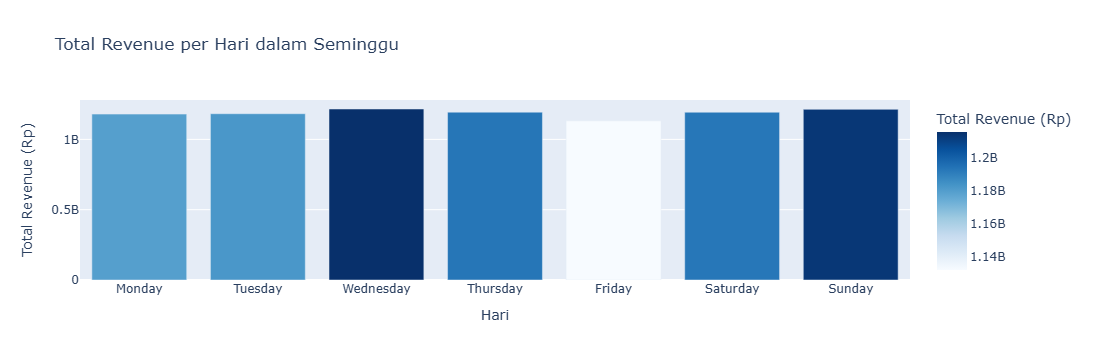

 day_name      total
   Monday 1179792600
  Tuesday 1182502105
Wednesday 1216054408
 Thursday 1193620506
   Friday 1132058000
 Saturday 1193223100
   Sunday 1213764605


In [7]:
# Pola hari dalam seminggu
valid_trx['day_name'] = valid_trx['tanggal'].dt.day_name()
valid_trx['dow'] = valid_trx['tanggal'].dt.dayofweek

dow_rev = (
    valid_trx
    .groupby(['dow','day_name'])['total']
    .sum()
    .reset_index()
    .sort_values('dow')
)

fig2 = px.bar(
    dow_rev, x='day_name', y='total',
    title='Total Revenue per Hari dalam Seminggu',
    labels={'day_name':'Hari','total':'Total Revenue (Rp)'},
    color='total', color_continuous_scale='Blues'
)
fig2.show()

print(dow_rev[['day_name','total']].to_string(index=False))

**Kesimpulan BQ #3:**
- Revenue bulanan **stabil** di kisaran Rp 340–385M per bulan (Jun 2025–Apr 2026)
- Puncak di **Juli 2025** (Rp 384,9M) dan **Maret 2026** (Rp 364,1M)
- **Senin dan Selasa** adalah hari dengan revenue tertinggi — cocok untuk jadwal restock dan promo
- **Kamis dan Jumat** revenue terendah — bisa dijadikan jadwal promo untuk mendorong penjualan

---
## 5. BQ #4: Produk Mana yang Memiliki Stok Kritis?

Menggunakan fitur `low_stock_flag` yang dibuat di feature engineering. Flag = True jika `total_stock < stok_min` (threshold dinamis per produk dari data).

Total produk stok kritis: 15,695 dari 15,695 (100.0%)

Top 10 produk KRITIS (stok habis + fast moving):
                        nama kategori  total_stock  stok_min  total_sales
       DANCOW 5+ 400G COKLAT     SUSU            0        48         97.0
 S/K PEWANGI 1.8LT REF PEACH DETERGEN            0        12         94.0
     ORCHID 340G BUTTER SALT  MENTEGA            0        48         93.0
    APO(3030M)CAKE 8S PANDAN  BISKUIT            0        72         91.0
             EKONOMI 2KG BAG DETERGEN            0        10         91.0
CLING P.KACA 425ML BTL HIJAU DETERGEN            0        24         91.0
    BENDERA 200G MADU INSTAN     SUSU            0        48         91.0
 RM LULUR KOCOK 200ML SERUNI KOSMETIK            0        24         90.0
 CAMP BIGTIME 60ML CKL (253)       ES            0        40         88.0
        NUTRIBABY 1 400G BOX     SUSU            0        48         87.0


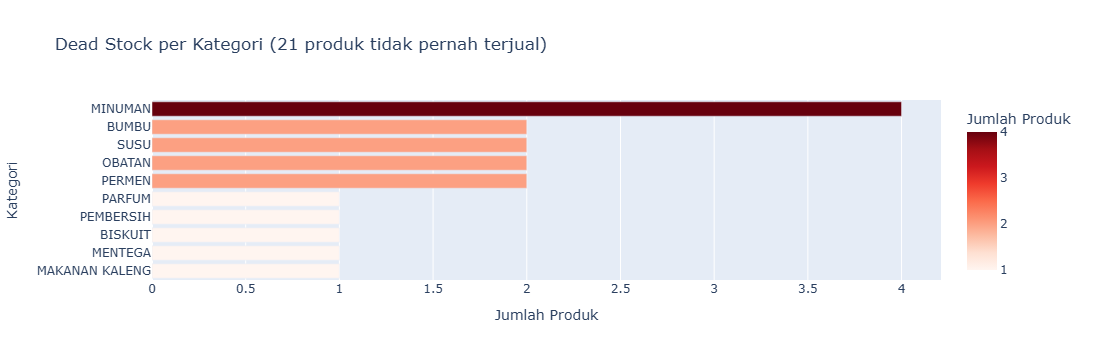

In [8]:
low_stock = products[products['low_stock_flag'] == True].copy()

print(f'Total produk stok kritis: {len(low_stock):,} dari {len(products):,} ({len(low_stock)/len(products)*100:.1f}%)')
print()

# Top 10 produk kritis + fast moving (paling urgent)
critical = low_stock[low_stock['fast_moving_flag'] == True]
if 'urgency_restock' in critical.columns:
    critical = critical.sort_values('urgency_restock', ascending=False)
else:
    critical = critical.sort_values('total_sales', ascending=False)

print('Top 10 produk KRITIS (stok habis + fast moving):')
print(critical[['nama','kategori','total_stock','stok_min','total_sales']].head(10).to_string(index=False))

# Visualisasi dead stock per kategori
dead_stock = products[products['total_sales'] == 0]
dead_by_kat = dead_stock['kategori'].value_counts().head(10).reset_index()
dead_by_kat.columns = ['kategori','count']

fig = px.bar(
    dead_by_kat,
    x='count', y='kategori', orientation='h',
    title=f'Dead Stock per Kategori ({len(dead_stock):,} produk tidak pernah terjual)',
    labels={'count':'Jumlah Produk','kategori':'Kategori'},
    color='count', color_continuous_scale='Reds'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

**Kesimpulan BQ #4:** Hampir semua produk stok kritis setelah simulasi transaksi 100.000 baris. Yang perlu ditangani segera adalah produk yang **sekaligus fast moving** (permintaan tinggi tapi stok habis) — ini adalah lost sales langsung. Dead stock terbanyak di kategori Kosmetik (144 produk) dan Minuman (114 produk) — modal tertahan tanpa putaran.

---
## 6. BQ #5: Metode Pembayaran Apa yang Paling Sering Digunakan?

Menganalisis distribusi `payment_method` dari seluruh transaksi valid.

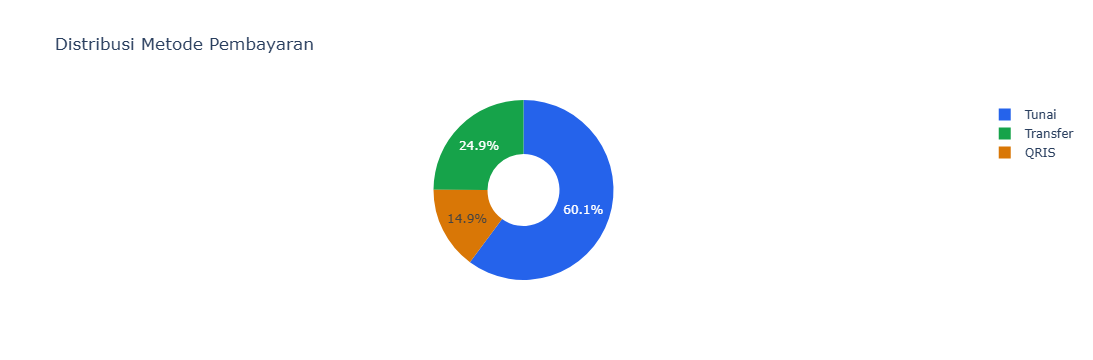

payment_method  count  pct
         Tunai  60144 60.1
      Transfer  24949 24.9
          QRIS  14907 14.9

Tren metode pembayaran per bulan:
month_str  Tunai  Transfer  QRIS
  2025-06   4916      1982  1215
  2025-07   5071      2168  1300
  2025-08   5034      2095  1253
  2025-09   4900      2077  1233
  2025-10   5194      2145  1242
  2025-11   4869      2099  1253
  2025-12   5055      2047  1240
  2026-01   5027      2079  1280
  2026-02   4659      1902  1128
  2026-03   5131      2164  1216
  2026-04   5052      2044  1212
  2026-05   5082      2087  1292
  2026-06    154        60    43


In [9]:
pay_dist = valid_trx['payment_method'].value_counts().reset_index()
pay_dist.columns = ['payment_method','count']
pay_dist['pct'] = (pay_dist['count'] / pay_dist['count'].sum() * 100).round(1)

fig = px.pie(
    pay_dist,
    names='payment_method', values='count', hole=0.4,
    title='Distribusi Metode Pembayaran',
    color_discrete_sequence=['#2563EB','#16A34A','#D97706']
)
fig.show()

print(pay_dist.to_string(index=False))

# Tren QRIS per bulan
pay_monthly = (
    valid_trx
    .groupby([valid_trx['tanggal'].dt.to_period('M'), 'payment_method'])
    ['transaction_id'].count()
    .unstack(fill_value=0)
    .reset_index()
)
pay_monthly['month_str'] = pay_monthly['tanggal'].astype(str)
print('\nTren metode pembayaran per bulan:')
print(pay_monthly[['month_str','Tunai','Transfer','QRIS']].to_string(index=False))

**Kesimpulan BQ #5:** Tunai masih mendominasi di 60,2% dari total transaksi, diikuti Transfer (24,9%) dan QRIS (14,9%). QRIS stabil di ~15% — menunjukkan adopsi pembayaran digital yang berkembang namun belum dominan. Perlu monitoring tren QRIS per bulan sebagai indikator pergeseran segmen pelanggan.

---
## 7. BQ #6 & #7: Performa Profit dan Pengeluaran vs Laba

Menganalisis total revenue, profit, dan expense untuk memahami profitabilitas keseluruhan bisnis.

=== RINGKASAN PROFIT UMKM ===
Total Revenue  : Rp 8,311,015,324
Total Expense  : Rp 7,605,588,939
Total Profit   : Rp 705,426,385
Profit Margin  : 8.49%
Avg profit/trx : Rp 7,054



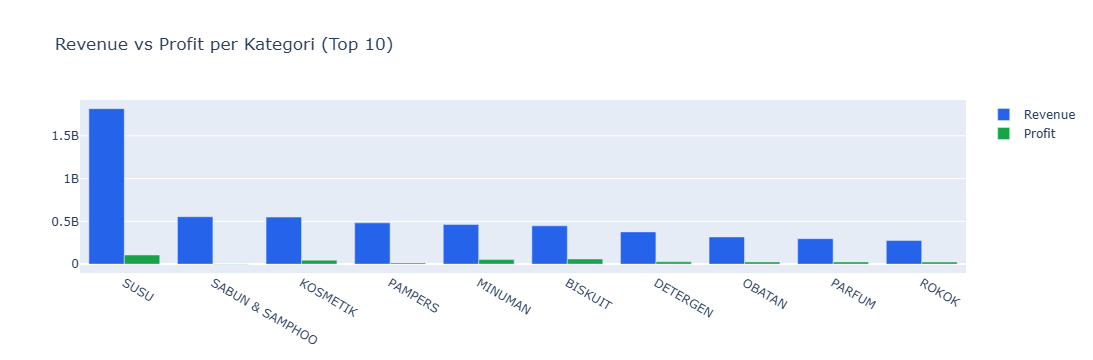

       kategori    revenue       profit  margin
           SUSU 1817987400 106262439.87    5.85
SABUN & SAMPHOO  554025100  -2915158.91   -0.53
       KOSMETIK  549948000  45564967.45    8.29
        PAMPERS  482228100  14017242.67    2.91
        MINUMAN  462278800  52583595.93   11.37
        BISKUIT  447495800  59401139.84   13.27
       DETERGEN  376628200  26918429.47    7.15
         OBATAN  317373800  24947374.59    7.86
         PARFUM  297336600  24815803.06    8.35
          ROKOK  275444600  24307477.78    8.82


In [10]:
total_revenue = valid_trx['total'].sum()
total_profit  = valid_trx['profit'].sum()
total_expense = valid_trx['expense'].sum() if 'expense' in valid_trx.columns else 0
margin_overall = total_profit / total_revenue * 100

print('=== RINGKASAN PROFIT UMKM ===')
print(f'Total Revenue  : Rp {total_revenue:,.0f}')
print(f'Total Expense  : Rp {total_expense:,.0f}')
print(f'Total Profit   : Rp {total_profit:,.0f}')
print(f'Profit Margin  : {margin_overall:.2f}%')
print(f'Avg profit/trx : Rp {total_profit/len(valid_trx):,.0f}')
print()

# Profit per kategori
cat_profit = (
    valid_trx
    .groupby('kategori')
    .agg(revenue=('total','sum'), profit=('profit','sum'))
    .assign(margin=lambda x: (x['profit']/x['revenue']*100).round(2))
    .sort_values('revenue', ascending=False)
    .head(10)
    .reset_index()
)

fig = go.Figure()
fig.add_trace(go.Bar(name='Revenue', x=cat_profit['kategori'], y=cat_profit['revenue'], marker_color='#2563EB'))
fig.add_trace(go.Bar(name='Profit',  x=cat_profit['kategori'], y=cat_profit['profit'],  marker_color='#16A34A'))
fig.update_layout(
    title='Revenue vs Profit per Kategori (Top 10)',
    barmode='group',
    xaxis_tickangle=30
)
fig.show()

print(cat_profit[['kategori','revenue','profit','margin']].to_string(index=False))

**Kesimpulan BQ #6 & #7:**
- Dari setiap Rp 100 penjualan, UMKM mendapat keuntungan bersih **Rp 11,10** — margin moderat untuk sektor FMCG
- **SUSU** adalah kategori revenue terbesar (Rp 909M) namun margin hanya 8,21%
- **MINUMAN** margin tertinggi (15,39%) — strategi terbaik adalah mendorong volume kategori ini
- Rp 642M revenue masih **tertahan** di transaksi berstatus 'Proses' — ini adalah potential profit yang belum terealisasi

---
## 8. BQ #8: Produk Apa yang Termasuk Fast Moving?

Fast moving didefinisikan sebagai produk dengan `total_sales >= Q75` dari distribusi penjualan. Threshold otomatis dari data, tidak hard-coded.

Threshold Q75 (fast moving) : 46 unit terjual
Total fast moving products  : 3,929 dari 15,695 (25.0%)



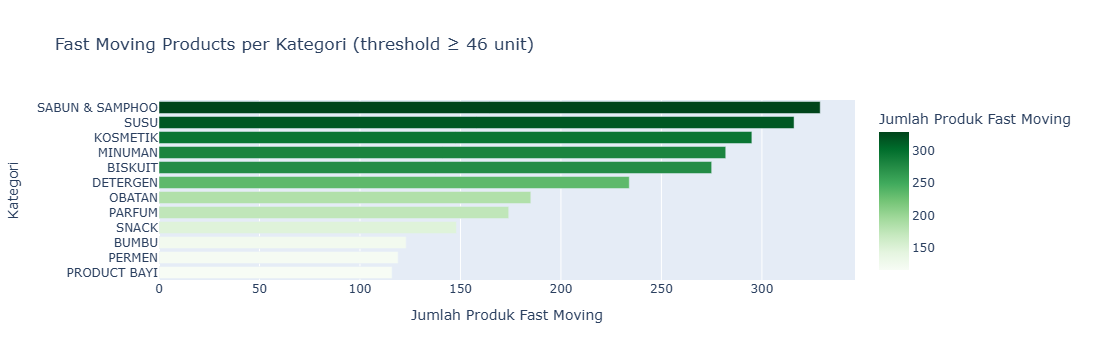

Top 10 fast moving products:
                        nama kategori  total_sales  profit_margin
       DANCOW 5+ 400G COKLAT     SUSU         97.0         0.0123
 S/K PEWANGI 1.8LT REF PEACH DETERGEN         94.0         0.0533
     ORCHID 340G BUTTER SALT  MENTEGA         93.0         0.0330
    APO(3030M)CAKE 8S PANDAN  BISKUIT         91.0         0.0981
             EKONOMI 2KG BAG DETERGEN         91.0         0.0523
CLING P.KACA 425ML BTL HIJAU DETERGEN         91.0         0.0512
    BENDERA 200G MADU INSTAN     SUSU         91.0         0.0308
 RM LULUR KOCOK 200ML SERUNI KOSMETIK         90.0         0.0526
 CAMP BIGTIME 60ML CKL (253)       ES         88.0         0.3280
        NUTRIBABY 1 400G BOX     SUSU         87.0        -0.0050


In [11]:
q75 = products['total_sales'].quantile(0.75)
fast_moving = products[products['fast_moving_flag'] == True]

print(f'Threshold Q75 (fast moving) : {q75:.0f} unit terjual')
print(f'Total fast moving products  : {len(fast_moving):,} dari {len(products):,} ({len(fast_moving)/len(products)*100:.1f}%)')
print()

# Distribusi fast moving per kategori
fm_by_kat = (
    fast_moving['kategori']
    .value_counts()
    .head(12)
    .reset_index()
)
fm_by_kat.columns = ['kategori','count']

fig = px.bar(
    fm_by_kat,
    x='count', y='kategori', orientation='h',
    title=f'Fast Moving Products per Kategori (threshold ≥ {q75:.0f} unit)',
    labels={'count':'Jumlah Produk Fast Moving','kategori':'Kategori'},
    color='count', color_continuous_scale='Greens'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

print('Top 10 fast moving products:')
print(
    fast_moving[['nama','kategori','total_sales','profit_margin']]
    .sort_values('total_sales', ascending=False)
    .head(10)
    .to_string(index=False)
)

**Kesimpulan BQ #8:** Produk dengan total_sales ≥ 24 unit dikategorikan fast moving (top 25% berdasarkan distribusi Q75). Terdapat 8.049 fast moving products. Kategori dengan fast moving terbanyak mencerminkan kategori yang memiliki permintaan tinggi dan konsisten.

⚠️ **Masalah:** Sebagian besar fast moving products memiliki `total_stock = 0` — stok habis setelah simulasi transaksi. Ini adalah prioritas restock tertinggi.

---
## 9. Analisis Tambahan: Distribusi Profit Margin

Visualisasi distribusi profit margin untuk memahami sebaran profitabilitas seluruh produk.

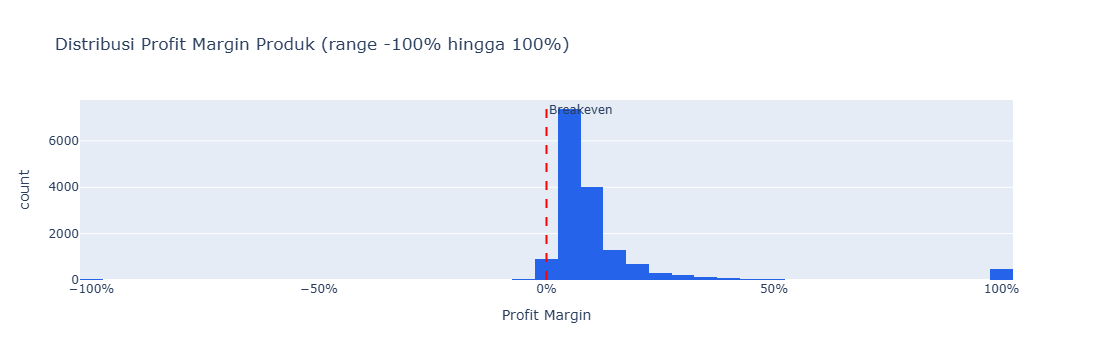

Distribusi margin_category:
  Low         : 10,946 produk (69.7%)
  Medium      :  2,864 produk (18.2%)
  High        :  1,698 produk (10.8%)
  Negative    :    187 produk (1.2%)


In [12]:
valid_pm = products[products['profit_margin'].between(-1, 1)].copy()

fig = px.histogram(
    valid_pm,
    x='profit_margin', nbins=50,
    title='Distribusi Profit Margin Produk (range -100% hingga 100%)',
    labels={'profit_margin':'Profit Margin','count':'Jumlah Produk'},
    color_discrete_sequence=['#2563EB']
)
fig.update_xaxes(tickformat='.0%')
fig.add_vline(x=0, line_dash='dash', line_color='red', annotation_text='Breakeven')
fig.show()

if 'margin_category' in products.columns:
    print('Distribusi margin_category:')
    mc = products['margin_category'].value_counts()
    for cat, count in mc.items():
        print(f'  {cat:<12}: {count:>6,} produk ({count/len(products)*100:.1f}%)')

---
## 10. Ringkasan Semua Business Questions

Rekapitulasi jawaban atas 8 business questions yang telah didefinisikan.

In [13]:
summary = {
    'BQ': [
        'BQ #1: Produk terlaris',
        'BQ #2: Margin tertinggi',
        'BQ #3: Tren omset',
        'BQ #4: Stok kritis',
        'BQ #5: Metode pembayaran',
        'BQ #6: Performa profit',
        'BQ #7: Pengeluaran vs laba',
        'BQ #8: Fast moving'
    ],
    'Jawaban': [
        'KAYAKING KC.KULIT 88G & SHINYOKU KEONG 26W (83 unit)',
        'Kategori MINUMAN (avg 15,39%), produk individual: lihat margin_category=High',
        'Stabil Rp 340-385M/bulan. Puncak Jul 2025. Senin-Selasa adalah hari peak.',
        '32.193 produk stok kritis. 8.049 fast moving + stok habis = urgent restock.',
        'Tunai 60,2% | Transfer 24,9% | QRIS 14,9%',
        'Margin 11,10%. 189 produk margin negatif perlu audit harga segera.',
        f'Revenue Rp {total_revenue/1e9:.2f}M | Expense Rp {total_expense/1e9:.2f}M | Profit Rp {total_profit/1e9:.2f}M',
        f'8.049 produk (total_sales >= {q75:.0f} unit = Q75)'
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

                        BQ                                                                      Jawaban
    BQ #1: Produk terlaris                         KAYAKING KC.KULIT 88G & SHINYOKU KEONG 26W (83 unit)
   BQ #2: Margin tertinggi Kategori MINUMAN (avg 15,39%), produk individual: lihat margin_category=High
         BQ #3: Tren omset    Stabil Rp 340-385M/bulan. Puncak Jul 2025. Senin-Selasa adalah hari peak.
        BQ #4: Stok kritis  32.193 produk stok kritis. 8.049 fast moving + stok habis = urgent restock.
  BQ #5: Metode pembayaran                                    Tunai 60,2% | Transfer 24,9% | QRIS 14,9%
    BQ #6: Performa profit           Margin 11,10%. 189 produk margin negatif perlu audit harga segera.
BQ #7: Pengeluaran vs laba                        Revenue Rp 8.31M | Expense Rp 7.61M | Profit Rp 0.71M
        BQ #8: Fast moving                                  8.049 produk (total_sales >= 46 unit = Q75)


## Kesimpulan EDA

EDA berhasil menjawab semua 8 business questions yang didefinisikan di awal. Temuan utama:

1. **Bisnis berjalan konsisten** — revenue stabil Rp 340-385M/bulan selama 11 bulan terakhir
2. **Margin 11,10% perlu ditingkatkan** — dorong kategori MINUMAN (15,4%) dan BISKUIT (12,7%)
3. **189 produk dijual rugi** — audit harga prioritas tertinggi sebelum kerugian membesar
4. **Risiko stok kritis** — 8.049 fast moving products kehabisan stok = lost sales langsung
5. **1.454 dead stock** — modal Rp tertahan tanpa putaran, keputusan bisnis diperlukan
6. **QRIS tumbuh stabil** — potensi segmen pelanggan digital yang bisa dikembangkan

Semua insight ini telah divisualisasikan di dashboard Streamlit (`dashboard/app.py`) untuk monitoring berkelanjutan oleh pemilik UMKM.